In [1]:

from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw, ImageFont
import ana_utils
from matplotlib import pyplot as plt
import scipy as sp
import nilearn as nil
from nilearn import plotting
from scipy.stats import f_oneway
import statsmodels.api as sm
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import nibabel as nib
from brainspace.mesh.mesh_io import read_surface
from netneurotools.metrics import *

from PIL import Image, ImageDraw, ImageFont
import pingouin as pg
from scipy.stats import pearsonr

global micapipe

HOME = f"D:/Shanghaitec/PROJECT/CSVD_neo"
micapipe = f"D:\Shanghaitec\PROJECT\communication\micapipe-master"

# HOME = f"/home/lingbin/share/CSVD"
# micapipe = f"/home/lingbin/Downloads/micapipe-master"
font_path = f"{HOME}/font/FreeSans.ttf" 

# Assuming you have a sans-serif font installed on your system
# font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 48)
# font_bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 56)

font = ImageFont.truetype("C:/Users/Ken/AppData/Local/Microsoft/Windows/Fonts/DejaVuSans.ttf",48)
font_bold = ImageFont.truetype("C:/Users/Ken/AppData/Local/Microsoft/Windows/Fonts/DejaVuSans-Bold.ttf",56)

DISGROUPS =  ana_utils.DISGROUPS
LM_LAB_ARR = ana_utils.LM_LAB
CM_ARR =ana_utils.CM_ARR[1:]
CM_NAME_ARR = [cm[0] for cm in CM_ARR]
CM_ARR_SHORT = ana_utils.CM_ARR_SHORT
mean_diff_labs = ana_utils.mean_diff_lab
network_abbreviations = ana_utils.net_abbr
yeo7_dict = ana_utils.YEO7_DICT
net_labs = yeo7_dict.keys()
PLT3 = ana_utils.PAL4
diag_col= ana_utils.diag_col
sub_list = ana_utils.SUB_ID_LIST
print(len(sub_list))

d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
d:\ProgramFiles\Anaconda3\lib\site-packages\nilearn\datasets\__init__.py:93: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  warn("Fetchers from the nilearn.datasets module will be "


Subjects from execel:  616
SUB_ID_LIST: list, format is like this:  sub-286 , and total length of SUB_ID_LIST = 371 {'naMCI': 79, 'aMCI': 116, 'NCI': 176}
371


In [ ]:

def load_annot(atlas, surf='fsaverage5'):
    '''
    Script that loads the labels of an specific parcellation and generates a midwall mask
    '''

    # Load LEFT annotation file in fsaverage5
    annot_lh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/lh.{atlas}_mics.annot')

    # Unique number of labels of a given atlas
    Ndim = max(np.unique(annot_lh_fs5[0]))

    if surf == 'fsaverage5':

        # Load RIGHT annotation file in fsaverage5
        annot_rh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/rh.{atlas}_mics.annot')[0]+Ndim

        # replace with 0 the medial wall of the right labels
        annot_rh_fs5 = np.where(annot_rh_fs5==Ndim, 0, annot_rh_fs5)

        # fsaverage5 labels
        labels = np.concatenate((annot_lh_fs5[0], annot_rh_fs5), axis=0)

    else:
        # Read label for fsLR-32k
        labels = np.loadtxt(open(f'{micapipe}/parcellations/{atlas}_conte69.csv'), dtype=int)

    # mask of the medial wall
    mask = labels != 0

    # Midwall labels of aparc-a2009s are lh=42 and rh=117
    if atlas == 'aparc-a2009s' and surf == 'fsaverage5':
        mask[(labels == 117) | (labels == 42)] = 0

    #print(f'{atlas}; midwall = {Ndim}, length = {str(labels.shape)}')

    return(labels, mask, Ndim)


def plotbrain(cm_mat, out_put_file, vmin , vmax, cmap="RdBu_r", size=(1200, 300), layout_style="row"):
    
    # Load fsaverage5 inflated
    fs5_lh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/lh.inflated', itype='fs')
    fs5_rh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/rh.inflated', itype='fs')

    # Load fsaverage5 labels
    labels_fs5, mask_fs5, _ = load_annot("schaefer-200", surf='fsaverage5')

    grad = map_to_labels(cm_mat, labels_fs5, mask=mask_fs5, fill=np.nan)
    plot_hemispheres(
        fs5_lh,
        fs5_rh,
        color_range=(vmin,vmax),
        cmap=cmap,
        array_name=grad,
        size=size,
        nan_color=(255, 255, 255, 1),
        screenshot=True,
        # background=(1,1,1),
        layout_style = layout_style,
        filename=f"{out_put_file}.png",
    )


In [3]:
# from nilearn.connectome import ConnectivityMeasure
# # from nilearn.maskers import MultiNiftiLabelsMasker
# from nilearn import plotting
# from nilearn import datasets

# shaefer = datasets.fetch_atlas_schaefer_2018(n_rois = 200)
# coordinates = plotting.find_parcellation_cut_coords(labels_img=shaefer["maps"])


In [4]:
def fiter_fc(matrix):

    # 找到最大和最小值
    max_val = np.max(matrix)
    min_val = np.min(matrix)

    # 计算阈值
    top_10_percent = 0.05
    top_10_percent_max = max_val - (max_val - min_val) * top_10_percent
    bottom_10_percent_min = min_val + (max_val - min_val) * top_10_percent

    # 置为0
    matrix[(matrix > top_10_percent_max) | (matrix < bottom_10_percent_min)] = 0
    return matrix, min_val, max_val

# Run above

# SUb info

In [55]:
info_tbl.columns

NameError: name 'info_tbl' is not defined

In [ ]:
from scipy.stats import chi2_contingency


info_tbl = ana_utils.sub_info_tbl
info_tbl = info_tbl[info_tbl.pid.isin(sub_list)]
info_tbl["gender_dig"] = info_tbl["gender"].apply(lambda x: 1 if x == "M" else 0)
info_tbl["Group"] = info_tbl[diag_col]

print(len(info_tbl))

columns = ["age", "edu_year", "logwmh", "门诊MMSE", "MoCA-merge", "门诊ADL"]
contingency_table = pd.crosstab(info_tbl["gender_dig"], info_tbl[diag_col])
display(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(chi2, p, dof)

merged_tbl = pd.DataFrame({diag_col: [*DISGROUPS,"F","p"]}).set_index(diag_col)

for col in columns:
    res_tbl = info_tbl.groupby(diag_col)[col].describe().round(2).reset_index()

    f, _, p, _, postp, _ = ana_utils.pg_anova(info_tbl, col)
    print(f"{col}: F={round(f,3)}, p={round(p,3)}")

    res_tbl[col] = res_tbl.apply(lambda x: f"{x['mean']:.2f} ± {x['std']:.2f}", axis=1)
    res_tbl.loc["3"] = [
        "F",
        *["1" for i in range(len(res_tbl.columns) - 2)],
        round(f, 3),
    ]
    res_tbl.loc["4"] = [
        "p",
        *["1" for i in range(len(res_tbl.columns) - 2)],
        round(p, 3),
    ]
    merged_tbl = merged_tbl.merge(
        res_tbl[[diag_col, col]],
        on=diag_col,
    )

# Display the merged table
display(merged_tbl)

In [ ]:
# 循环输出描述统计信息
for col in columns:
    res_tbl = info_tbl.groupby(diag_col)[col].describe().round(2).reset_index()
    res_tbl[col] = res_tbl.apply(lambda x: f"{x['mean']:.2f} ± {x['std']:.2f}", axis=1)
    merged_tbl = merged_tbl.merge(res_tbl[[diag_col, col]], on=diag_col, suffixes=('_' + columns[0], '_' + col))

    display(res_tbl)

    f, _, p, _, postp, _ = ana_utils.pg_anova(info_tbl, col)
    print(f"{col}: F={round(f,3)}, p={round(p,3)}")


    
# Display the merged table
display(merged_tbl)

# Plot mats of typical subject 

In [ ]:
figures_to_merge = []

typical_subs = [ 'sub-129','sub-184','sub-164']

typical_subs = [ 'sub-231','sub-413','sub-097']

for sub_id in typical_subs:
    
    figures_to_merge.append(f"{HOME}/data/cm-fig/{sub_id}-wb_fg-wei.png")
    for col in CM_NAME_ARR:
        filename = f"{HOME}/data/cm-fig/{sub_id}-wb_{col}.png"
        figures_to_merge.append(filename)
    figures_to_merge.append(f"{HOME}/data/fc-fig/{sub_id}_fc-wb_schaefer-200.png")
        
ana_utils.plot_create_image_grid(figures_to_merge, 3, len(CM_NAME_ARR)+2, 0, f"{HOME}/figures/typical-wb.png")

# Plot lr correlation 

In [93]:

lm_method = "lr_glob_lm_cfc"
merged_tbl = pd.DataFrame()
for lm_lab in LM_LAB_ARR[1:]:
    for cm_lab in CM_NAME_ARR:
        # print(lm_lab, cm)
        df = pd.read_csv(f"{HOME}/results/{lm_method}/{cm_lab}-cfc_{lm_lab}.csv")
        df = df.assign(lm=lm_lab)
        df = df.assign(cm=cm_lab)
        merged_tbl = pd.concat([merged_tbl, df],axis=0)
        
merged_tbl["lmcm"] = merged_tbl["lm"]+"-"+merged_tbl["cm"]


<Axes: >

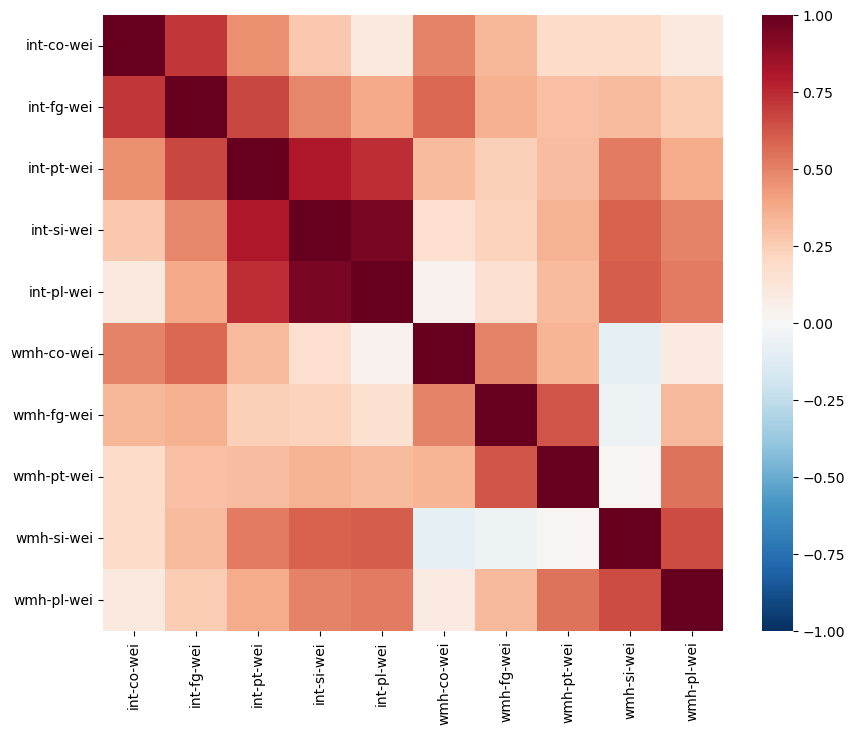

In [98]:
corr_matrix = pd.DataFrame(
    index=merged_tbl["lmcm"].unique(), columns=merged_tbl["lmcm"].unique()
)
for lm1 in merged_tbl["lmcm"].unique():
    for lm2 in merged_tbl["lmcm"].unique():
        data_lm1 = merged_tbl[merged_tbl["lmcm"] == lm1]["rsq"]
        data_lm2 = merged_tbl[merged_tbl["lmcm"] == lm2]["rsq"]
        corr, p_value = pearsonr(data_lm1, data_lm2)
        corr_matrix.loc[lm1, lm2] = corr
corr_matrix

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix.astype(float), 
    annot=False, cmap="RdBu_r", fmt=".2f", vmax=1, vmin=-1
)

In [76]:
stop

NameError: name 'stop' is not defined

# Plot flow graphs coupling rsq

In [ ]:
int_df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_int.csv").set_index(["pid", "Group","idx","cm"])
wmh_df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_wmh.csv").set_index(["pid", "Group","idx","cm"])

df_tbl = int_df.rsq - wmh_df.rsq
df_tbl.to_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_int-wmh.csv")

['#FA7F6f', '#FFBE7A', '#82B0D2']
[ 0  1  2  3  4  5  6  7  8  9 10]


/tmp/ipykernel_1422031/2302458245.py:39: UserWarning:

FixedFormatter should only be used together with FixedLocator



[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]


/tmp/ipykernel_1422031/2302458245.py:39: UserWarning:

FixedFormatter should only be used together with FixedLocator



[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]


/tmp/ipykernel_1422031/2302458245.py:39: UserWarning:

FixedFormatter should only be used together with FixedLocator



[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]


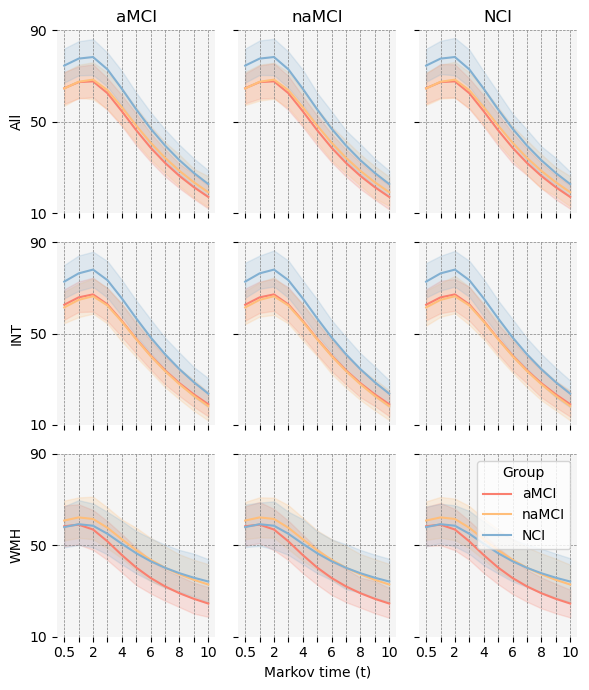

In [169]:
# Paired plot
print(PLT3)
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]

import numpy as np
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(3, 3, figsize=(6, 7))
# plt.rcParams.update({'font.size': 12})

lm_method = "corr_glob_lm_cfc"
lm_labs = [*LM_LAB_ARR, "int-wmh"]
lm_labs = LM_LAB_ARR
for j, lm_lab in enumerate(lm_labs):
    for i, group in enumerate(DISGROUPS):
        df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_{lm_lab}.csv")
        print(df.idx.unique())
        # df = df[df.Group == group]
        # df[df.idx == 0] = 0.5
        df.dropna()
        sns.lineplot(
            x="idx",
            y="rsq",
            ax=axes[j, i],
            palette=ana_utils.PAL4,
            hue="Group",
            data=df,
            hue_order=ana_utils.DISGROUPS,
            legend=True if j == 2 and i == 2 else False,
            # color=ana_utils.PAL4[i]
        )

        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(["All","INT","WMH"][j])
            axes[j, i].set_yticklabels([10,50,90])

        if j == 0:  # First row
            axes[j, i].set_title(group)
        axes[j, i].set_ylim(df["rsq"].quantile(0.1), df["rsq"].quantile(0.9))
        axes[j, i].set_yticks((np.linspace(df["rsq"].quantile(0.1), df["rsq"].quantile(0.9), num=3, endpoint=True)))

        axes[j, i].xaxis.set_major_locator(FixedLocator([0, *range(1, 11)]))
        if j == 2:  # Last row
            # axes[j, i].set_ylim(0.00, 0.06)
            # axes[j, i].set_yticks((np.linspace(0.00, 0.06, num=4, endpoint=True)))
            axes[j, i].set_xticklabels([0.5, "", 2, "", 4, "", 6, "", 8, "", 10])
        else:
            # axes[j, i].set_ylim(0.00, 0.12)
            # axes[j, i].set_yticks((np.linspace(0.00, 0.12, num=4, endpoint=True)))

            axes[j, i].set_xticklabels([])
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)

        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color="gray", linestyle="--", linewidth=0.5, which="major")
        axes[j, i].set_facecolor("whitesmoke")


plt.tight_layout()
plt.savefig(f"{HOME}/figures/flow-graph_markov-{lm_method}.pdf")
plt.show()

['#FA7F6f', '#FFBE7A', '#82B0D2']
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10]


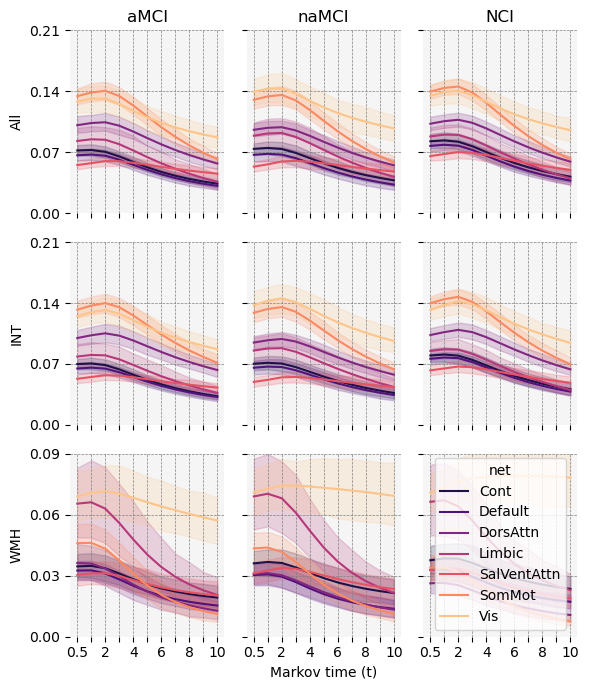

In [ ]:
# Paired plot
print(PLT3)
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]
import pingouin as pg
import numpy as np
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(3, 3, figsize=(6, 7))
# plt.rcParams.update({'font.size': 12})

lm_method = "corr_net_lm_cfc"
for j, lm_lab in enumerate(LM_LAB_ARR):
    for i, group in enumerate(DISGROUPS):
        df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_{lm_lab}.csv")
        print(df.idx.unique())
        df = df[df.Group == group]
        # df[df.idx == 0] = 0.5
        df.dropna()
        sns.lineplot(
            x="idx",
            y="rsq",
            hue="net",
            ax=axes[j, i],
            palette="magma",
            data=df,
            legend=True if j == 2 and i == 2 else False,
        )

        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(["All", "INT", "WMH"][j])

        if j == 0:  # First row
            axes[j, i].set_title(group)
        axes[j, i].xaxis.set_major_locator(FixedLocator([0, *range(1, 11)]))
        if j == 2:  # Last row
            axes[j, i].set_ylim(0.00, 0.09)
            axes[j, i].set_yticks((np.linspace(0.00, 0.09, num=4, endpoint=True)))
            axes[j, i].set_xticklabels([0.5, "", 2, "", 4, "", 6, "", 8, "", 10])
        else:
            axes[j, i].set_ylim(0.00, 0.21)
            axes[j, i].set_yticks((np.linspace(0.00, 0.21, num=4, endpoint=True)))

            axes[j, i].set_xticklabels([])
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)

        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color="gray", linestyle="--", linewidth=0.5, which="major")
        axes[j, i].set_facecolor("whitesmoke")


plt.tight_layout()
plt.savefig(f"{HOME}/figures/flow-graph_markov-{lm_method}.pdf")
plt.show()

In [ ]:
lm_method = "corr_net_lm_cfc"
int_df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_int.csv").set_index(["pid", "Group","idx","cm","net"])
wmh_df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_wmh.csv").set_index(["pid", "Group","idx","cm","net"])

df_tbl = int_df.rsq - wmh_df.rsq
df_tbl.to_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_int-wmh.csv")

['#FA7F6f', '#FFBE7A', '#82B0D2']


/tmp/ipykernel_73474/1733497988.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[j, i].set_yticklabels([10,50,90])
/tmp/ipykernel_73474/1733497988.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[j, i].set_yticklabels([10,50,90])
/tmp/ipykernel_73474/1733497988.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[j, i].set_yticklabels([10,50,90])


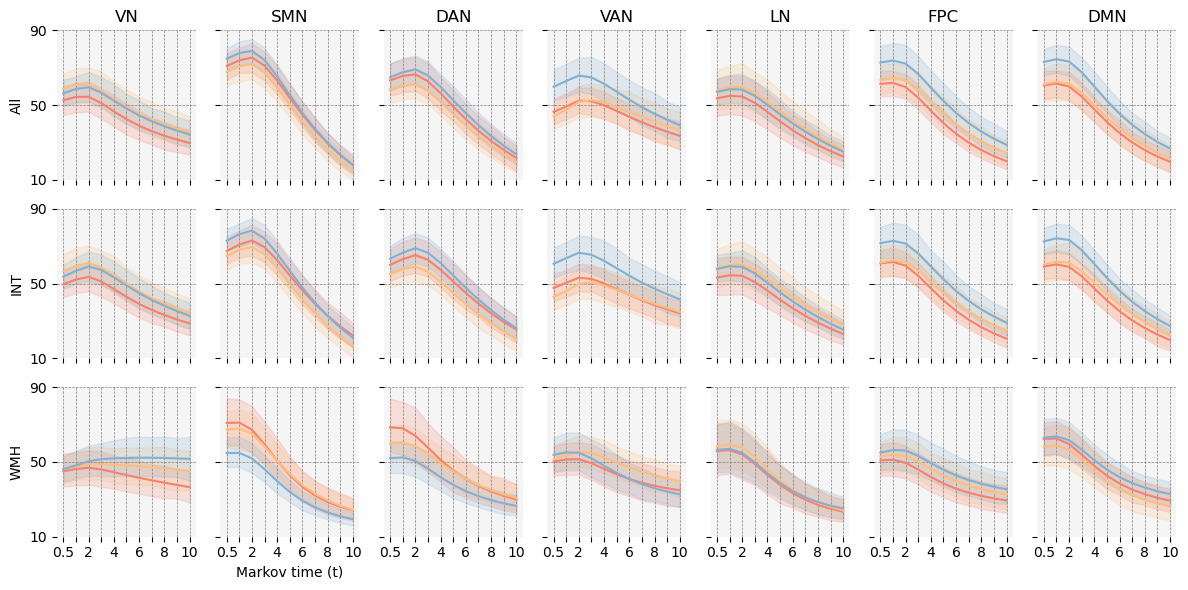

In [62]:
# Paired plot
print(PLT3)
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]
import pingouin as pg
import numpy as np
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(3, 7, figsize=(12, 6))
lm_labs = [*LM_LAB_ARR, "int-wmh"]
lm_labs = LM_LAB_ARR
lm_method = "corr_net_lm_cfc"
for j, lm_lab in enumerate(lm_labs):
    for i, net_lab in enumerate(list(ana_utils.net_abbr.keys())):
        df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_{lm_lab}.csv")
        df = df[(df.net == net_lab)&(df.idx < 11)]
        df.dropna()
        sns.lineplot(
            x="idx",
            y="rsq",
            hue="Group",
            ax=axes[j, i],
            palette=PLT3,
            data=df,
            hue_order=DISGROUPS,
            legend=False 
        )

        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(["All","INT","WMH"][j])
            axes[j, i].set_yticklabels([10,50,90])

        if j == 0:  # First row
            axes[j, i].set_title(network_abbreviations[net_lab])
            
        axes[j, i].xaxis.set_major_locator(FixedLocator([0, *range(1, 11)]))
        axes[j, i].set_ylim(df["rsq"].quantile(0.1), df["rsq"].quantile(0.9))
        axes[j, i].set_yticks((np.linspace(df["rsq"].quantile(0.1), df["rsq"].quantile(0.9), num=3, endpoint=True)))

        if j == 2:  # Last row
            axes[j, i].set_xticklabels([0.5, "", 2, "", 4, "", 6, "", 8, "", 10])
        else:
           
            axes[j, i].set_xticklabels([])
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)

        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color="gray", linestyle="--", linewidth=0.5, which="major")
        axes[j, i].set_facecolor("whitesmoke")
        # axes[j, i].legend("")
plt.gca.legend_ =False
plt.tight_layout() 
plt.savefig(f"{HOME}/figures/flow-graph_markov-{lm_method}_sortbynet.pdf")
plt.show()

In [77]:
# ANOVA plot
comp_res = {
    "lm_lab": [],
    "net": [],
    # "t": [],
    "p": [],
}
for j, lm_lab in enumerate(lm_labs):
    fg_df = pd.read_csv(f"{HOME}/results/{lm_method}/fg-wei-cfc_{lm_lab}.csv")
    fg_df = fg_df[fg_df.idx<6]
    for i, net_lab in enumerate(list(ana_utils.net_abbr.keys())):
        df = fg_df[fg_df.net == net_lab]
        
        anova_res = pg.mixed_anova(data=df, dv='rsq', between='Group', within='idx',
                     subject='pid', correction=False, effsize="np2")
        if anova_res["p-unc"][0] < 0.09:
            print(lm_lab, net_lab)
            display(anova_res)
        comp_res["lm_lab"].append(lm_lab)
        comp_res["net"].append(net_lab)
        comp_res["p"].append(anova_res["p-unc"][0] if anova_res["p-unc"][0] < 0.05 else "")
        # display(pd.DataFrame(comp_res))
pd.DataFrame(comp_res).to_csv(f"{HOME}/results/fg_significant.csv")


wb SalVentAttn


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.019483,2,142,0.009741,2.906010,5.795357e-02,0.039320,NaN
1,idx,0.003237,5,710,0.000647,23.147296,1.422679e-21,0.140162,0.213519
2,Interaction,0.000690,10,710,0.000069,2.468065,6.612461e-03,0.033594,NaN


wb Default


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.021851,2,142,0.010925,2.969278,5.453743e-02,0.040142,NaN
1,idx,0.037390,5,710,0.007478,426.176040,5.472576e-211,0.750077,0.232544
2,Interaction,0.000170,10,710,0.000017,0.970508,4.677808e-01,0.013485,NaN


int SalVentAttn


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.023148,2,142,0.011574,3.718879,2.665559e-02,0.049772,NaN
1,idx,0.002850,5,710,0.000570,23.799169,3.638854e-22,0.143542,0.214259
2,Interaction,0.000441,10,710,0.000044,1.840788,5.049319e-02,0.025271,NaN


int Default


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.022868,2,142,0.011434,3.234145,4.231354e-02,0.043567,NaN
1,idx,0.030953,5,710,0.006191,404.139669,6.730092e-205,0.739993,0.233816
2,Interaction,0.000218,10,710,0.000022,1.424182,1.649355e-01,0.019664,NaN


wmh SomMot


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.019140,2,142,0.009570,2.633770,7.531352e-02,0.035769,NaN
1,idx,0.039557,5,710,0.007911,237.810504,5.202015e-149,0.626129,0.228151
2,Interaction,0.000631,10,710,0.000063,1.895920,4.266952e-02,0.026009,NaN


In [ ]:
# ANOVA plot
comp_res = {
    "lm_lab": [],
    "net": [],
    "t": [],
    "p": [],
    mean_diff_labs[0]: [],
    mean_diff_labs[1]: [],
    mean_diff_labs[2]: [],
}
for j, lm_lab in enumerate(LM_LAB_ARR):
    fg_df = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/fg-wei-cfc_{lm_lab}.csv")
    for m, net_lab in enumerate(list(net_labs)):

        df = fg_df[fg_df.net == net_lab]
        for t in df.idx.unique():
            # df = df[df.Group==group]

            anova_res = ana_utils.anova(df[df.idx == t], "rsq")
            comp_res["lm_lab"].append(lm_lab)
            comp_res["net"].append(net_lab)
            comp_res["t"].append(t)
            comp_res["p"].append(anova_res[1] if anova_res[1] < 0.05 else "")
            for i, dif_lab in enumerate(mean_diff_labs):
                comp_res[dif_lab].append(anova_res[2][i])
# display(pd.DataFrame(comp_res))
pd.DataFrame(comp_res).to_csv(f"{HOME}/results/fg_significant.csv")

# Tmax

In [23]:

tmax_tbl = {
    "lm":[],
    "net": [],
    "pid": [],
    "tmax": [],
}
for j, lm_lab in enumerate(LM_LAB_ARR):
    fg_df = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/fg-wei-cfc_{lm_lab}.csv")
    for m, net_lab in enumerate(list(net_labs)):

        fg_df_net = fg_df[fg_df.net == net_lab]
        for sub_id in df.pid.unique():
            fg_df_net_sub = fg_df_net[fg_df_net.pid == sub_id]
            x = np.array(fg_df_net_sub.idx)
            y = np.array(fg_df_net_sub.rsq)
            coefficients = np.polyfit(x, y, 4)
            fitted_curve = np.poly1d(coefficients)

            max_y = np.max(fitted_curve(x))
            max_t = x[np.argmax(fitted_curve(x))]  # 对应的时间点
            tmax_tbl["lm"].append(lm_lab)
            tmax_tbl["tmax"].append(max_t)
            tmax_tbl["net"].append(net_lab)
            tmax_tbl["pid"].append(sub_id)
tmax_df = pd.DataFrame(tmax_tbl)
tmax_df["Group"] = tmax_df["pid"].apply(lambda x: ana_utils.SUB_ID_DIAG_DICT[x])

In [33]:
for j, lm_lab in enumerate(LM_LAB_ARR):
    for m, net_lab in enumerate(list(net_labs)):
        df = tmax_df[(tmax_df.net==net_lab) & (tmax_df.lm==lm_lab)]
        com_res = pg.anova(df, dv="tmax", between="Group")
        com_res = com_res.assign(lm=lm_lab)
        com_res = com_res.assign(net=net_lab)
        display(com_res)

,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.305194,0.737463,0.00428,wb,Cont


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.018993,0.981189,0.000267,wb,Default


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.448051,0.639772,0.006271,wb,DorsAttn


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.325873,0.722435,0.004569,wb,Limbic


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,2.323791,0.101614,0.031692,wb,SalVentAttn


...

,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.426873,0.653381,0.005976,wmh,DorsAttn


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,1.805636,0.168123,0.024801,wmh,Limbic


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,2.70933,0.070024,0.036757,wmh,SalVentAttn


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,0.668011,0.514331,0.009321,wmh,SomMot


,Source,ddof1,ddof2,F,p-unc,np2,lm,net
0,Group,2,142,3.777429,0.025214,0.050516,wmh,Vis


# Plot CO


In [ ]:
# Selection of typical subjects with distinct rsqs
co_rsq_tbl = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/co-wei-cfc_int.csv")
co_rsq_tbl["sex"] = co_rsq_tbl["pid"].map(ana_utils.SUB_ID_GEN_DICT)

sub_info_tbl = ana_utils.sub_info_tbl[["pid","age","logwmh"]]
co_rsq_match = pd.merge(left=co_rsq_tbl, right=sub_info_tbl, on="pid")
co_rsq_match = co_rsq_match.sort_values(by="rsq")
display(co_rsq_match[co_rsq_match.pid =="sub-599"])
display(co_rsq_match[co_rsq_match.pid =="sub-073"])
display(co_rsq_match[co_rsq_match.pid =="sub-303"])
co_rsq_match

,pid,Group,cm,idx,rsq,sex,age,logwmh
118,sub-599,NCI,lrm,0,0.048798,0,69.0,4.549921


,pid,Group,cm,idx,rsq,sex,age,logwmh
119,sub-073,naMCI,lrm,0,0.02484,1,69.0,4.595893


,pid,Group,cm,idx,rsq,sex,age,logwmh
88,sub-303,aMCI,lrm,0,0.017512,0,68.0,4.25159


,pid,Group,cm,idx,rsq,sex,age,logwmh
101,sub-345,naMCI,lrm,0,0.012891,0,59.0,3.451172
108,sub-231,aMCI,lrm,0,0.013660,0,71.0,4.022511
88,sub-303,aMCI,lrm,0,0.017512,0,68.0,4.251590
126,sub-096,NCI,lrm,0,0.020177,0,59.0,4.667864
10,sub-339,naMCI,lrm,0,0.020911,1,63.0,3.594393
...,...,...,...,...,...,...,...,...
131,sub-256,naMCI,lrm,0,0.051294,0,55.0,3.971925
109,sub-360,NCI,lrm,0,0.051480,0,51.0,3.286456
82,sub-219,NCI,lrm,0,0.051500,0,59.0,3.593977
2,sub-509,NCI,lrm,0,0.057102,0,60.0,3.455600


In [ ]:
# sub_id_list = ["sub-153", "sub-464"] # 153 Dem, 464 NC Long longer used
sub_id_list = ["sub-599", "sub-303", "sub-073"] # 241 NCI
sub_id = sub_id_list[1]
cm_name = "co"
cm_name = "pl"

In [ ]:
# Plot FC
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")
fc = np.power(fc, 2)
# fc =  sp.stats.zscore(fc)
# fc,vmin, vmax  = fiter_fc(fc)
np.fill_diagonal(fc, 0)
fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_wb_fg-wei_schaefer-200.npy")[3]
# fc = sp.stats.zscore(fc)
plotting.plot_connectome(
    fc,
    coordinates,
    title="",
    edge_threshold="90%",
    node_color="white",
    edge_cmap="RdBu_r",
    display_mode="x",
    colorbar=False,
    node_size=0,
    edge_vmin=np.nanpercentile(fc, 91),
    edge_vmax=np.nanpercentile(fc, 99),
    alpha=0.6,
    edge_kwargs={
        "alpha": 0.3,
           "linewidth":2
    },
    output_file=f"{HOME}/figures/co/{sub_id}-fc.png",
)

In [ ]:
for lm_lab in LM_LAB_ARR:
    plot_mat = np.load(f"{HOME}/data/cm/{cm_name}-wei/{sub_id}_{lm_lab}_{cm_name}-wei_schaefer-200.npy")[0]
    np.fill_diagonal(plot_mat, 0)
    plot_mat = np.power(plot_mat,-1)
    plotting.plot_connectome(
        plot_mat,
        coordinates,
        title="",
        edge_threshold="90%",
        node_color="white",
        edge_cmap="RdBu_r",
        display_mode="x",
        colorbar=False,
        node_size=0,
        edge_vmin=np.nanpercentile(plot_mat, 91),
        edge_vmax=np.nanpercentile(plot_mat, 99),
        alpha=0.6,
        edge_kwargs={"alpha": 0.3,"linewidth":2},
        output_file=f"{HOME}/figures/co/{lm_lab}.png",
    )

sub_fg_subplots = [f"{HOME}/figures/co/{lm_lab}.png" for lm_lab in LM_LAB_ARR]

sub_fg_subplots.append(f"{HOME}/figures/co/{sub_id}-fc.png")

ana_utils.plot_create_image_grid(
    sub_fg_subplots,
    1,
    4,
    50,
    f"{HOME}/figures/co/{sub_id}-{lm_lab}_{cm_name}_time.png",
)
# sub_fg_timelines.append(f"{HOME}/figures/co/{sub_id}-{lm_lab}_fg_time.png")

# ana_utils.plot_create_image_grid(
#     sub_fg_timelines, 3, 1, 0, f"{HOME}/figures/co-merge_{sub_id}.png"
# )

/tmp/ipykernel_1378997/2120054798.py:4: RuntimeWarning: divide by zero encountered in power
  plot_mat = np.power(plot_mat,-1)


In [ ]:
stop 

NameError: name 'stop' is not defined

# Plot brain network using nilearn
## Global

In [ ]:
# Selection of typical subjects with distinct rsqs
fg_rsq_tbl = pd.read_csv(f"{HOME}/results/corr_glob_lm_cfc/fg-wei-cfc_wb.csv")
fg_rsq_tbl["sex"] = fg_rsq_tbl["pid"].map(ana_utils.SUB_ID_GEN_DICT)
sub_info_tbl = ana_utils.sub_info_tbl[["pid","age","logwmh"]]
fg_rsq_tbl = fg_rsq_tbl[fg_rsq_tbl.idx==2]
fg_rsq_match = pd.merge(left=fg_rsq_tbl, right=sub_info_tbl, on="pid")
fg_rsq_match = fg_rsq_match.sort_values(by="rsq")
# display(fg_rsq_match[fg_rsq_match.Group=="MCI"])
# display(fg_rsq_match[fg_rsq_match.Group=="Dementia"])
display(fg_rsq_match[fg_rsq_match.pid =="sub-097"])
display(fg_rsq_match[fg_rsq_match.pid =="sub-123"])

,pid,Group,cm,idx,rsq,pval,sex,age,logwmh
57,sub-097,NCI,fg-wei,2,0.160148,0.0,1,65.0,4.117801


,pid,Group,cm,idx,rsq,pval,sex,age,logwmh
56,sub-123,aMCI,fg-wei,2,0.057206,6.997161e-257,0,67.0,4.111397


In [ ]:
# sub_id_list = ["sub-153", "sub-464"] # 153 Dem, 464 NC Long longer used
sub_id_list = ["sub-097", "sub-123"] # 153 Dem, 118 MCI
sub_id = sub_id_list[0]

In [ ]:
# Plot FC
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")
fc = np.power(fc,2)
# fc =  sp.stats.zscore(fc)
# fc,vmin, vmax  = fiter_fc(fc)
np.fill_diagonal(fc,0)
fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_wb_fg-wei_schaefer-200.npy")[3]
 
plotting.plot_connectome(fc, coordinates, title="FC", 
    edge_threshold="95%",
    node_color = "white",
    edge_cmap = "RdBu_r",  
    display_mode = "x", colorbar= False,
    node_size=0, 
    edge_vmin = 0, 
    edge_vmax = np.max(fc)*0.5,
    alpha = 0.6,
    edge_kwargs ={"alpha" :0.6,
                #    "linewidth":2
                   },
    output_file = f"{HOME}/figures/fg/{sub_id}-fc.png")


In [ ]:
sub_fg_timelines = []
for lm_lab in LM_LAB_ARR:
    fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_{lm_lab}_fg-wei_schaefer-200.npy")

    mt_list = [0.5, 1, 2, 3, 4, 5, 10]
    for i in range(len(mt_list)):
        timestamp = "t=" + str(mt_list[i]) if lm_lab == "wb" else ""
        plot_mat = fg_mt[i]
        np.fill_diagonal(plot_mat, 0)

        plotting.plot_connectome(
            plot_mat,
            coordinates,
            title="",
            edge_threshold="95%",
            node_color="white",
            edge_cmap="RdBu_r",
            display_mode="x",
            colorbar=False,
            node_size=0,
            edge_vmin=0,
            edge_vmax=np.nanmax(plot_mat) * 0.5,
            alpha=0.5,
            edge_kwargs={"alpha": 0.8},
            output_file=f"{HOME}/figures/fg/{round(mt_list[i])}.png",
        )

    sub_fg_subplots = [f"{HOME}/figures/fg/{round(mt)}.png" for mt in mt_list]
    if lm_lab == "wb":
        sub_fg_subplots.append(f"{HOME}/figures/fg/{sub_id}-fc.png")
    # if lm_lab == "int":
    #     sub_fg_subplots.append(f"{HOME}/figures/wmh_2d_{sub_id}.png")

    ana_utils.plot_create_image_grid(
        sub_fg_subplots,
        1,
        len(mt_list) + 1,
        10,
        f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time.png",
    )
    sub_fg_timelines.append(f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time.png")

ana_utils.plot_create_image_grid(
    sub_fg_timelines, 3, 1, 0, f"{HOME}/figures/fg-merge_{sub_id}.png"
)

In [ ]:
stop

NameError: name 'stop' is not defined

## net

In [ ]:
# Plot FC
sub_id = sub_id_list[0]
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")
fc = np.power(fc, 2)
np.fill_diagonal(fc, 0)
net_lab = "salienceVentralAttention"
net_lab = "Vis"
net_lab = "Default"
# net_lab = "Limbic"
net_lab = "SalVentAttn"
bool_array = np.full((200, 200), False)
for index in yeo7_dict[net_lab]:
    bool_array[index, :] = True
    bool_array[:, index] = True

fc[~bool_array] = 0
# fc = sp.stats.zscore(fc)
# fc = fc / np.max(fc)
# fc = fc.astype(np.float32)
plotting.plot_connectome(
    fc,
    coordinates,
    title="",
    edge_threshold="95%",
    node_color="white",
    edge_cmap="RdBu_r",
    display_mode="x",
    colorbar=False,
    node_size=0,
    edge_vmin=0,
    edge_vmax=np.nanmax(fc) * 0.5,
    alpha=0.6,
    edge_kwargs={
        "alpha": 0.6,
        #   "solid_capstyle":"round"
        #   "linestyle":'-',
        #    "linewidth":2,
    },
    output_file=f"{HOME}/figures/fg/{sub_id}-fc-{net_lab}.png",
)

In [ ]:
sub_fg_timelines = []
for lm_lab in LM_LAB_ARR:
    fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_{lm_lab}_fg-wei_schaefer-200.npy")

    mt_list = [0.5, 1, 2, 3, 4, 5, 10]
    for i in range(len(mt_list)):
        timestamp = "t=" + str(mt_list[i]) if lm_lab == "wb" else ""
        plot_mat = fg_mt[i]
        np.fill_diagonal(plot_mat, 0)

        bool_array = np.full((200, 200), False)
        for index in yeo7_dict[net_lab]:
            bool_array[index, :] = True
            bool_array[:, index] = True
        # net_idx_list  = yeo7_dict["salienceVentralAttention"]
        # for m in yeo7_dict["salienceVentralAttention"]:
        #     for n in yeo7_dict["salienceVentralAttention"]:
        #         bool_array[m, n]=True

        plot_mat[~bool_array] = 0
        # plotting.plot_matrix(plot_mat, cmap="RdBu_r",grid=False)
        # plt.savefig(f"{HOME}/figures/fg/{round(mt_list[i])}-fg-mat.png")
        plotting.plot_connectome(
            plot_mat,
            coordinates,
            # title=timestamp,
            edge_threshold="95%",
            node_color="white",
            edge_cmap="RdBu_r",
            display_mode="x",
            colorbar=False,
            node_size=0,
            edge_vmin=0,
            edge_vmax=np.nanmax(plot_mat)*0.5,
            alpha=0.5,
            edge_kwargs={"alpha": 0.5},
            output_file=f"{HOME}/figures/fg/{round(mt_list[i])}-{net_lab}.png",
        )

    sub_fg_subplots = [f"{HOME}/figures/fg/{round(mt)}-{net_lab}.png" for mt in mt_list]
    if lm_lab == "wb":
        sub_fg_subplots.append(f"{HOME}/figures/fg/{sub_id}-fc-{net_lab}.png")
    ana_utils.plot_create_image_grid(
        sub_fg_subplots,
        1,
        len(mt_list) + 1,
        0,
        f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time-{net_lab}.png",
    )
    sub_fg_timelines.append(
        f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time-{net_lab}.png"
    )
ana_utils.plot_create_image_grid(
    sub_fg_timelines, 3, 1, 0, f"{HOME}/figures/fg-merge_{sub_id}-{net_lab}.png"
)

In [ ]:
# Plot FC
sub_id = sub_id_list[0]
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")
fc = np.power(fc, 2)
np.fill_diagonal(fc,0)
# net_lab = "Vis"
net_lab = "Default"
cmb_mat =  np.full((200,200), 0.0) 
bool_array = np.full((200,200), False) 
for index in yeo7_dict[net_lab]:
    bool_array[index,:] = True  
    bool_array[:,index] = True  

fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_wb_fg-wei_schaefer-200.npy")[3]
fg_mt = sp.stats.zscore(fg_mt)
fc = sp.stats.zscore(fc)

cmb_mat[np.tril_indices(200,1)] = fg_mt[np.tril_indices(200,1)] 
cmb_mat[np.triu_indices(200,1)] = fc[np.triu_indices(200,1)] 
np.fill_diagonal(cmb_mat, 0)
reg_cmb_mat = cmb_mat

# Swich for global or local 
# reg_cmb_mat = np.where(bool_array, cmb_mat, np.nan)

fig, axes = plt.subplots(figsize=(8, 8))
axes.axis("off")
axes.set_facecolor("white")
plotting.plot_matrix(cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="gray",
            axes=axes,
            vmin=-5,
            vmax=5,)
plotting.plot_matrix(reg_cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="RdBu_r",
            axes=axes,
            vmin=-2,
            vmax=2,)
reg_cmb_mat[np.triu_indices(200,1)]=np.nan
plotting.plot_matrix(reg_cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="RdBu_r",
            axes=axes,
            vmin=-2,
            vmax=2,)

# axes.set_frame_on(True)
# plt.plot(range(200), range(200), color='black',linewidth=1,)
# plt.plot(np.repeat(99.5,200), range(200), color='black',linewidth=0.5,)
# plt.plot(range(200),np.repeat(99.5,200),  color='black',linewidth=0.5,)
plt.title("")

# plt.savefig(f"{HOME}/figures/fig4_merge-connectome_global_{sub_id}.svg",dpi=300)
plt.savefig(f"{HOME}/figures/fig5_merge-connectome_glob-{net_lab}_{sub_id}.svg",dpi=300)

IndentationError: expected an indented block after 'for' statement on line 2 (3381638124.py, line 3)

In [ ]:
stop here

SyntaxError: invalid syntax (4067800170.py, line 1)

## Plot WMH

In [ ]:
from skimage import measure
from scipy.ndimage import median_filter
from skimage import filters

sub_id = sub_id_list[0]
print(sub_id)
wm_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0002.nii.gz").get_fdata()
ctx_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0000.nii.gz").get_fdata()
ven_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0003.nii.gz").get_fdata()
wmh_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0004.nii.gz").get_fdata()

sub-097


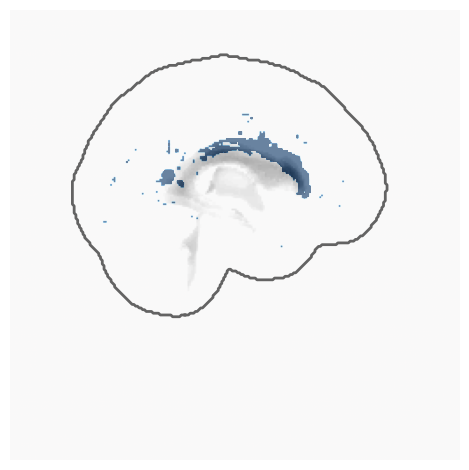

In [ ]:
wmh_2d = np.sum(wmh_img, axis=0)
# ctx_img = wm_img
plt.figure(facecolor="white")
ctx_img = filters.gaussian(np.sum(ctx_img ,axis=0).astype(float), sigma=5)

contours = np.round(measure.find_contours(ctx_img, 0.8))
for contour in contours:
    plt.plot(contour[:,1],contour[:,0],linewidth=2,color="black",alpha=0.6,
            #  ,cmap="gray_r",vmin=0,vmax=10
            )

    
plt.imshow(np.sum(ven_img ,axis=0),cmap="gray_r",alpha=1, vmin=0,vmax=30)
plt.imshow(wmh_2d,cmap="RdBu", alpha=0.6,vmin=-1,vmax=1)
plt.grid(False)
plt.axis(False)
plt.tight_layout()
plt.savefig(f"{HOME}/figures/wmh_2d_{sub_id}.png", dpi=300)


In [ ]:
stop here

SyntaxError: invalid syntax (4067800170.py, line 1)

# Plot Atlas Legend for Yeo's 7 or 17 networks

In [ ]:
# ana_utils.YEO7_DICT
image_to_merge = []
for i , net_lab in enumerate(ana_utils.YEO7_DICT.keys()):
    
    zero_200 = np.zeros(200)
    net_idx = ana_utils.YEO7_DICT[net_lab]
    zero_200[net_idx]=-1
    out_filename = f"{HOME}/figures/atlas_{ana_utils.net_abbr[net_lab]}"
    plotbrain(zero_200, out_filename, -1,1, size = (600,600), layout_style="grid")
    plotbrain(zero_200, f"{out_filename}_row", -1,1)
    # read the saved image, and add text at the left top conner , text= ana_utils.net_abbr[net_lab],and save
    # Load the saved image
    image = Image.open(f"{out_filename}.png")
    draw = ImageDraw.Draw(image)
    # Define the text and font
    text = ana_utils.net_abbr[net_lab]
   
    # Get the size of the text
    left, top, right, bottom = draw.textbbox((0, 0), text, font)
    text_width, text_height = right - left, bottom - top

    position = (image.width // 2 - (text_width // 2)*0, 30)  # Center the text vertically

    # Add the text to the image
    draw.text(position, text, fill="black", font=font, anchor="mm")  # Set anchor to "nw" for top-left alignment

    image.save(f"{out_filename}.png")
    image_to_merge.append(f"{out_filename}.png")
# ana_utils.plot_create_image_grid(image_to_merge, 1, 7, 400, f"{HOME}/figures/atlas.png")


In [ ]:
from drawSvg import Drawing
import os


# Plot Yeo's 7 or 17 networks

In [5]:

# ana_method, meanorsig, items = "corr_net", "mean", DISGROUPS
# pb_vmax, df_vmin, df_vmax  = 0.2, -0.3,0.3

# ana_method, meanorsig, items = "corr_net", "sig", mean_diff_labs
# pb_vmax, df_vmin, df_vmax  = 0.2, -0.03,0.03 

# ana_method, meanorsig, items = "lr_net", "mean", DISGROUPS
# pb_vmax, df_vmin, df_vmax  = 0.05, -0.2,0.2

ana_method, meanorsig, items = "lr_net", "sig", mean_diff_labs
pb_vmax, df_vmin, df_vmax  = 0.05, -0.005,0.005

In [6]:
res_dir= f"{HOME}/results/{ana_method}_lm_cfc/"
# # Delete existing files
os.system(f"{HOME}/figures/tmp/* -type f -delete")

mean_rsq_tbl = pd.read_csv(f"{res_dir}/_mean_rsq_results.csv")
anova_res_tbl = pd.read_csv(f"{res_dir}/_comp_results_with_fdr.csv")

In [7]:
# Filter anova p values
# if "lr" in ana_method:
#     lr_model_res_tbl =  pd.read_csv(f"{res_dir}/_comp_results_lr.csv")
#     for index, row in lr_model_res_tbl.iterrows():
#         net , lm= row['net'], row['lm']
#         for posthoc_idx in range(3):
#             posthoc_p = row[f"posthoc_p_{posthoc_idx}"]
#             if row['p_group']>0.05 or posthoc_p > 0.05:
#                 anova_res_tbl.loc[(anova_res_tbl.net == net) & (anova_res_tbl.lm == lm), f"posthoc_p_{posthoc_idx}"] = 1
#                 anova_res_tbl.loc[(anova_res_tbl.net == net) & (anova_res_tbl.lm == lm), f"{mean_diff_labs[posthoc_idx]}"] = 0

for md_idx, md_lab in enumerate(mean_diff_labs):
    anova_res_tbl.loc[anova_res_tbl.fdr_p>0.05, f'posthoc_p_{md_idx}']=1
    anova_res_tbl.loc[anova_res_tbl[f'posthoc_p_{md_idx}'] > 0.05, md_lab] = 0

In [8]:
# Plot mean 
for dg in DISGROUPS:
    for cm in CM_NAME_ARR:
        for lm in LM_LAB_ARR:
            mean_rsq_gr = mean_rsq_tbl[(mean_rsq_tbl.lm == lm) & (mean_rsq_tbl.cm == cm)]
            group_data = np.zeros(200)
            for key in yeo7_dict.keys():
                for idx in yeo7_dict[key]:
                    group_data[idx] = mean_rsq_gr.loc[mean_rsq_gr['net'] == key, dg]
            plotbrain(group_data, f"{HOME}/figures/tmp/{ana_method}_{cm}-{lm}-{dg}", 0, pb_vmax)

C:\Users\Ken\AppData\Local\Temp\ipykernel_17472\1683961816.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  group_data[idx] = mean_rsq_gr.loc[mean_rsq_gr['net'] == key, dg]


In [9]:
for lm_lab in LM_LAB_ARR:
    for cm_lab in CM_NAME_ARR:
        anova_lm_cm_tbl = anova_res_tbl[(anova_res_tbl.lm == lm_lab)&
                                          (anova_res_tbl.cm == cm_lab)]
        
        for md_lab in mean_diff_labs:
            node_val_arr = np.zeros(200)
            for net_idx, net_lab in enumerate(net_labs):
                md_val = anova_lm_cm_tbl.loc[anova_lm_cm_tbl['net'] == net_lab, md_lab]
                # print(md_val)
                if len(md_val):
                    for node_idx in yeo7_dict[net_lab]:
                        if md_val.values[0]!=0:
                            node_val_arr[node_idx] = md_val.values[0]
                        
                        
                # print(np.sum(node_val_arr))
            plotbrain(node_val_arr, f"{HOME}/figures/tmp/{ana_method}_{cm_lab}-{lm_lab}-{md_lab}",df_vmin, df_vmax)


In [10]:
# from PIL import Image
# import os

# # 定义行和列的顺序
# rows = CM_NAME_ARR
# cols = LM_LAB_ARR

# # 定义要合并的文件标识


# # 遍历文件标识
# for identifier in mean_diff_labs:
#     images_to_combine = []
    
#     # 获取第一个图像的大小
#     first_image = Image.open(f"{HOME}/figures/tmp/{rows[0]}-{cols[0]}-{identifier}.png")
#     width, height = first_image.size
    
#     # 创建一个新的图像对象，用于合并
#     combined_image = Image.new('RGB', (len(cols)*width, len(rows)*height), color=(255, 255, 255))
    
#     # 遍历行和列
#     for i, row in enumerate(rows):
#         for j, col in enumerate(cols):
#             filename = f"{HOME}/figures/tmp/{row}-{col}-{identifier}.png"
#             if os.path.exists(filename):
#                 image = Image.open(filename)
#                 combined_image.paste(image, (j*width, i*height))
    
#     # 保存合并后的图像
#     output_filename = f"{HOME}/figures/{identifier}_combined.png"
#     combined_image.save(output_filename)


In [10]:
# Merge Columns
img1 = Image.open(f"{HOME}/figures/tmp/{ana_method}_si-wei-wb-NCI.png")
# new_width = img1.width * 2 + 250  # 加上左边框的宽度
# new_height = img1.height *2 - 50*2  # 加上上边框的高度

new_width = img1.width * 3 + 450  # 加上左边框的宽度
new_height = img1.height *3 - 50*2  # 加上上边框的高度

for cm in CM_NAME_ARR:
    new_img = Image.new('RGB', (new_width, new_height), color=(255, 255, 255))  # 白色背景
    # Paste the images onto the new image to form a 3x3 gridLM_LAB_ARR
    for i, item in enumerate(items):
        for j, lm in enumerate(LM_LAB_ARR):
            # 打开对应的图像
            img = Image.open(f"{HOME}/figures/tmp/{ana_method}_{cm}-{lm}-{item}.png")
            # 计算粘贴的位置
            x_offset = j * img1.width  +100*j
            y_offset = i * img1.height -50*i
            # 添加边框
            border_color = (0, 0, 0)  # 边框颜色为黑色
            if j>0:
                border_width = 1  # 边框宽度为5像素
            else:
                border_width = 0
            border=(border_width, 0, 0, 0), 
            img_with_border = ImageOps.expand(img, fill=border_color)
            # 粘贴图像到新图像上
            new_img.paste(img_with_border, (x_offset+100, y_offset))
            draw = ImageDraw.Draw(new_img)
            # ({lm.upper()})
            text_position = (x_offset+30+100, y_offset + 10)  # 文字位于图像上方中央
            
            draw.text(text_position, f"{item} ", font=font, fill=(0, 0, 0))
    # Save the final image
    new_img.save(f'{HOME}/figures/local_{ana_method}-{meanorsig}_comb_{cm}.png')

In [12]:
# Merge rows
images = []
image_names = [ f"{HOME}/figures/tmp/{ana_method}_comb_{cm}.png" for cm in CM_NAME_ARR ]
for name in image_names:
    img = Image.open(name)
    images.append(img)

# 确定合并后的图像大小
max_width = max(img.width for img in images)
total_height = sum(img.height for img in images)   # 总高度加上空白高度

# 创建一个新的图像，大小为最大宽度和总高度
new_img = Image.new('RGB', (max_width, total_height+100), color=(255, 255, 255))  # 白色背景

# 在左上角添加图像和对应的名字
draw = ImageDraw.Draw(new_img)
y_offset = 0
for img, name in zip(images, image_names):
    new_img.paste(img, (0, y_offset+100))
    
    y_offset += img.height # 图像高度加上空白高度
    # draw.rectangle((20,20,max_width,20+1),outline = "black",width=1)
# 保存合并后的图像
new_img.save(f"{HOME}/figures/3_{ana_method}_cfc_{meanorsig}.png")


FileNotFoundError: [Errno 2] No such file or directory: 'D:/Shanghaitec/PROJECT/CSVD_neo/figures/tmp/lr_net_comb_co-wei.png'

In [ ]:
stop here

SyntaxError: invalid syntax (4067800170.py, line 1)

In [ ]:
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Load the dataset
region_corr_tbl =pd.read_csv(f"{HOME}/results/{ana_method}_lm_cfc/_mean_rsq_results.csv")


df = pd.DataFrame()

# 使用melt函数将 'Dementia', 'MCI', 'NCI' 转换为列
df_melted = region_corr_tbl.melt(id_vars=['cm', 'lm', 'net'], value_vars=DISGROUPS, var_name='Group', value_name='Rsq')
df_pivot = df_melted.pivot(index=[ 'lm', 'net', 'Group'],columns="cm",values="Rsq").reset_index()
df_pivot["net"] = df_pivot["net"].apply(lambda x: network_abbreviations[x])
for lm in LM_LAB_ARR:
      # for lm in LM_LAB_ARR:
      plt_data = df_pivot[df_pivot.lm==lm]

      # Make the PairGrid
      g = sns.PairGrid(plt_data,
                        x_vars=CM_ARR,
                        y_vars="net",
                        hue="Group",
                        palette= ["#DB3124", "#FC8C5A", "#4B74B2"],
                        height=5,
                        aspect =0.5
                        )

      # Draw a dot plot using the stripplot function
      g.map(sns.stripplot, size=10, orient="h", jitter=False,
            linewidth=0)

      # Use the same x axis limits on all columns and add better labels
      g.set( xlabel="R${^2}$", ylabel="", xticks=np.linspace(0, 0.1, 3))

      # # Use semantically meaningful titles for the columns
      titles = CM_ARR_SHORT

      for ax, title in zip(g.axes.flat, titles):
            
            # Set a different title for each axes
            ax.set(title=title)

            # Make the grid horizontal instead of vertical
            ax.xaxis.grid(False)
            ax.yaxis.grid(True)

      sns.despine(left=True, bottom=True)
      g.fig.subplots_adjust(wspace=0.2)
      g.savefig(f"{HOME}/figures/{ana_method}pair_{lm}.png")

# Plot legend and colorbar

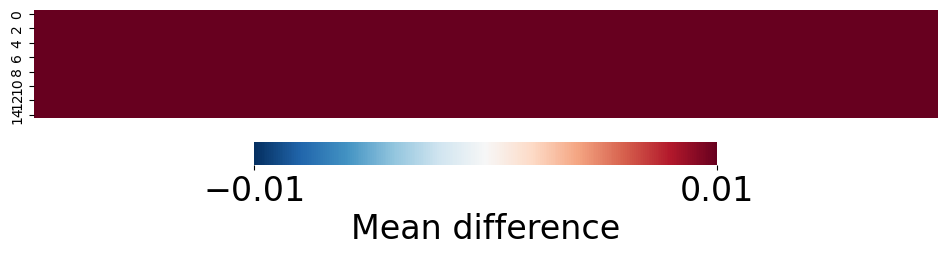

In [ ]:
fig, axe = plt.subplots(figsize=(10,3))
plt.rcParams.update({'font.size': 24}) 
sns.heatmap(np.random.random([15,5]),vmin=-0.01,vmax = 0.01, xticklabels="",
            cmap="RdBu_r",cbar_kws = {
    'label': 'Mean difference',  # 标签
    'orientation': 'horizontal',  # 刻度位置
    'ticks': [-0.01, 0.01],  # 刻度值
    'shrink': 0.7,  # 刻度大小
})
plt.tight_layout()
fig.savefig(f"{HOME}/figures/cbar.png", dpi=300)

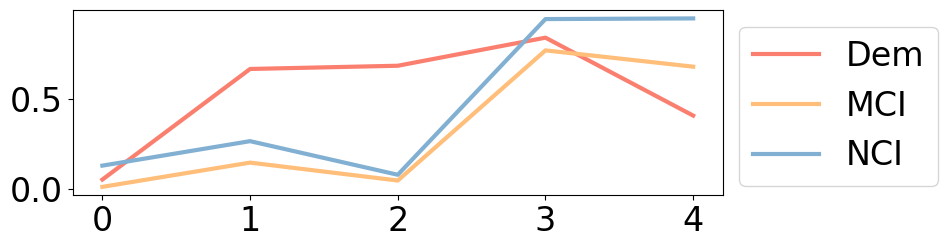

In [ ]:
fig, axe = plt.subplots(figsize=(10, 3))
plt.rcParams.update({'font.size': 24}) 
dummy_df = pd.DataFrame({"Dem":np.random.random(5),
                         "MCI":np.random.random(5),
                         "NCI":np.random.random(5)})
sns.lineplot(data=dummy_df, palette=ana_utils.PAL4, legend="full",
             dashes=False, sizes=30, linewidth=3)  # Increase the linewidth value (e.g., 2) as per your requirement

sns.move_legend(axe, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
fig.savefig(f"{HOME}/figures/legend.png", dpi=300)

# Mediation analysis


In [ ]:
roi_lab = "nawm"
# concentric = "_3"
concentric = ""
med_items = ["rd", "fa", "adc", "ad", "tfr", "log" + roi_lab]
#  "rd", "fa","adc", "ad","tfr","tfr", 

dwi_metric_csv = (
    f"{HOME}/results/lms_stat/4_wmh_dwi_metric{concentric}.csv"
    if roi_lab == "wmh"
    else f"{HOME}/results/lms_stat/2_wmh_dwi_metric{concentric}.csv"
)
cog_items = [
    "门诊MMSE",
    "MoCA-merge",
    "TMT(B-A)",
    # "Stroop A-T",
    # "Stroop B-T",
    # "Stroop C-T",
    "Stroop-TI",
    "Stroop-EI",
    "DS(f+b)",
    "DS-forward",
    "DS-backward",
    # "DSS",
    # "VFT",
    # "AVLT1",
    # "AVLT2",
    # "AVLT3",
    "AVLT4",
    "AVLT5",
    "AVLT再认",
    "AVLT(1+2+3)",
    "Rey-O回忆",
    "Rey-O再认",
    "Rey-O复制",
    "BNT",
]

# output_dir = f"{HOME}/results/med_{roi_lab}_concentric{concentric}"
output_dir = f"{HOME}/results/med_{roi_lab}"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [ ]:
# Get sub_info tbl
sub_info_tbl = pd.read_csv(f"{HOME}/data/filt_sub_info.csv", encoding="gbk")

sub_info_tbl["Stroop-TI"] = (
    sub_info_tbl["Stroop C-T"]
    - (sub_info_tbl["Stroop A-T"] + sub_info_tbl["Stroop B-T"]) * 0.5
)
sub_info_tbl["Stroop-EI"] = (
    50-sub_info_tbl["Stroop C-N"]
    - (50-sub_info_tbl["Stroop A-N"] + 50-sub_info_tbl["Stroop B-N"]) * 0.5
)


mean_edu_year = sub_info_tbl["edu_year"].mean().round()
# Fill education year nan to mean
sub_info_tbl["edu_year"].fillna(mean_edu_year, inplace=True)

# Get NAWM volume
nawm_tbl = pd.read_csv(
    f"{HOME}/results/lms_stat/nawm_volume_raw.csv", names=["pid", "nawm"]
)
nawm_tbl["lognawm"] = nawm_tbl["nawm"].apply(lambda x: np.log(x))
sub_info_tbl = pd.merge(sub_info_tbl, on="pid", right=nawm_tbl)

roi_tbl = pd.read_csv(
    dwi_metric_csv,
    names=["pid", "dwim", "val"],
)
wmh_met_pivot = roi_tbl.pivot_table(
    index="pid", values="val", columns="dwim"
).reset_index()
sub_info_tbl = pd.merge(sub_info_tbl, on="pid", right=wmh_met_pivot)

In [ ]:
cog_items = cog_items
sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in cog_items:
        for lm_lab in LM_LAB_ARR:
            for cm in ana_utils.CM_ARR[1:]:
                print(med_item, cog_item, lm_lab, cm)
                cm_lab, cm_idx, _ = cm
                # print(cog_item, lm, cm_lab)
                df = pd.read_csv(
                    f"{HOME}/results/corr_glob_lm_cfc/{cm_lab}-cfc_{lm_lab}.csv"
                )
                df = df[df.idx == cm_idx]

                df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
                df["edu_year"] = df["pid"].map(
                    sub_info_tbl.set_index("pid")["edu_year"].to_dict()
                )
                df["cog"] = df["pid"].map(
                    sub_info_tbl.set_index("pid")[cog_item].to_dict()
                )
                df[med_item] = df["pid"].map(
                    sub_info_tbl.set_index("pid")[med_item].to_dict()
                )

                df = df[~np.isnan(df["cog"])]
                df = df[df[med_item] > 0]
                pg_ma_res = pg.mediation_analysis(
                    data=df,
                    x=med_item,
                    m="rsq",
                    y="cog",
                    covar=["age", "edu_year"],
                    alpha=0.05,
                    n_boot=1000,
                    seed=42,
                )
                # Filter results according to the significance
                sig_list = pg_ma_res.sig.to_list()
                if (
                    sig_list[-1] == "Yes"
                    and sig_list[0] == "Yes"
                    and sig_list[1] == "Yes"
                ):
                    print("-------------------sig")
                    pg_ma_res = pg_ma_res.assign(
                        med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net="glob"
                    )
                    sum_res = pd.concat([sum_res, pg_ma_res])

    # Local CM-FC coupling mediation
    for cog_item in cog_items:
        for net_lab in yeo7_dict.keys():
            for lm_lab in LM_LAB_ARR:
                net_df = pd.DataFrame()
                print(cog_item, net_lab, lm_lab)
                for cm in ana_utils.CM_ARR[1:]:

                    cm_name, cm_idx, _ = cm

                    df = pd.read_csv(
                        f"{HOME}/results/lr_net_lm_cfc/{cm_name}-cfc_{lm_lab}.csv"
                    )
                    df.cm = cm_name
                    df = df[df.net == net_lab][
                        [
                            "pid",
                            "Group",
                            "cm",
                            "rsq",
                        ]
                    ]
                    net_df = pd.concat([net_df, df], ignore_index=True)

                net_df = pd.merge(
                    net_df,
                    right=sub_info_tbl.set_index("pid")[
                        ["age", "edu_year", cog_item, med_item]
                    ],
                    on="pid",
                )
                # display(net_df)
                net_df = net_df[net_df[med_item] > 0]
                net_pivot_df = net_df.pivot_table(
                    index=["pid", "Group", "age", "edu_year", cog_item, med_item],
                    columns="cm",
                    values="rsq",
                ).reset_index()

                pg_ma_res = pg.mediation_analysis(
                    data=net_pivot_df.copy(),
                    x=med_item,
                    m=CM_NAME_ARR,
                    y=cog_item,
                    covar=["age", "edu_year"],
                    alpha=0.05,
                    n_boot=1000,
                    seed=42,
                )
                # Filter results according to the significance
                sig_list = pg_ma_res.sig.to_list()
                issave = False
                for i in range(len(sig_list) - 12):
                    if (
                        sig_list[i] == "Yes"
                        and sig_list[i + 5] == "Yes"
                        and sig_list[i + 12] == "Yes"
                    ):
                        issave = True
                        print("-------------------sig")

                if issave:
                    print(net_lab, lm_lab)
                    pg_ma_res = pg_ma_res.assign(
                        med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net=net_lab
                    )
                    sum_res = pd.concat([sum_res, pg_ma_res])
                    fig, axes = plt.subplots(5, 3, figsize=(20, 30))

                    for j, cm_name in enumerate(CM_NAME_ARR):
                        # 第一个图
                        sns.regplot(
                            data=net_pivot_df, x=med_item, y=cog_item, ax=axes[j, 0]
                        )

                        # 第二个图
                        sns.regplot(
                            data=net_pivot_df, x=med_item, y=cm_name, ax=axes[j, 1]
                        )

                        # 第三个图
                        sns.regplot(
                            data=net_pivot_df, x=cm_name, y=cog_item, ax=axes[j, 2]
                        )

                    
                    # axes.set_title("")
                    # axes.set_ylabel("")
                    # axes.set_xlabel("")

                    plt.tight_layout()  # 确保图表正确排列
                    plt.savefig(
                        f"{output_dir}/{med_item}_{cog_item}_{lm_lab}_{net_lab}.svg",
                        dpi=50
                    )
    sum_res.to_csv(f"{output_dir}/mediaction_{med_item}_{roi_lab}.csv", encoding="gbk")

rd 门诊MMSE wb ('co-wei', 0, '#9A7BB7')


rd 门诊MMSE wb ('fg-wei', 3, '#9A7BB7')
rd 门诊MMSE wb ('pt-wei', 1, '#7B8CB7')
rd 门诊MMSE wb ('si-wei', 1, '#7B8CB7')
rd 门诊MMSE wb ('pl-wei', 1, '#999999')
rd 门诊MMSE int ('co-wei', 0, '#9A7BB7')
rd 门诊MMSE int ('fg-wei', 3, '#9A7BB7')
rd 门诊MMSE int ('pt-wei', 1, '#7B8CB7')
rd 门诊MMSE int ('si-wei', 1, '#7B8CB7')
rd 门诊MMSE int ('pl-wei', 1, '#999999')
rd 门诊MMSE wmh ('co-wei', 0, '#9A7BB7')
rd 门诊MMSE wmh ('fg-wei', 3, '#9A7BB7')
rd 门诊MMSE wmh ('pt-wei', 1, '#7B8CB7')
rd 门诊MMSE wmh ('si-wei', 1, '#7B8CB7')
rd 门诊MMSE wmh ('pl-wei', 1, '#999999')
rd MoCA-merge wb ('co-wei', 0, '#9A7BB7')
rd MoCA-merge wb ('fg-wei', 3, '#9A7BB7')
rd MoCA-merge wb ('pt-wei', 1, '#7B8CB7')
rd MoCA-merge wb ('si-wei', 1, '#7B8CB7')
rd MoCA-merge wb ('pl-wei', 1, '#999999')
rd MoCA-merge int ('co-wei', 0, '#9A7BB7')
rd MoCA-merge int ('fg-wei', 3, '#9A7BB7')
rd MoCA-merge int ('pt-wei', 1, '#7B8CB7')
rd MoCA-merge int ('si-wei', 1, '#7B8CB7')
rd MoCA-merge int ('pl-wei', 1, '#999999')
rd MoCA-merge wmh ('co-wei', 0, '

KeyboardInterrupt: 

In [ ]:
roi_lab = "wmh"
med_items = ["rd", "fa","ad","log"+roi_lab]
cog_items = ["门诊MMSE", "MoCA-merge","TMT(B-A)", 'Stroop A-T', 'Stroop B-T','Stroop C-T',  
       'DS(f+b)', 'DS-forward','DS-backward',  'AVLT1', 'AVLT2', 'AVLT3',
         'AVLT4','AVLT5', 'AVLT再认',  'Rey-O回忆', 'Rey-O再认','BNT']
# 'DSS', 'VFT', 'Rey-O复制','AVLT(1+2+3)',

sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in cog_items:
        
    
        df_fg = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/fg-wei-cfc_int.csv")
        df_fg = df_fg[df_fg.idx ==3].assign(cm="fg-wei")
        df_si = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/si-wei-cfc_wmh.csv")
        df_si = df_si[df_si.idx ==1].assign(cm="si-wei")
        df = pd.concat([df_fg, df_si]).pivot_table(
            values="rsq",index=["pid","Group"],columns ="cm").reset_index()
        df["fgsi"] = df["fg-wei"]+df["si-wei"]
        df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
        df["edu_year"] = df["pid"].map(sub_info_tbl.set_index("pid")["edu_year"].to_dict())
        df["cog"] = df["pid"].map(sub_info_tbl.set_index("pid")[cog_item].to_dict())
        df[med_item] = df["pid"].map(sub_info_tbl.set_index("pid")[med_item].to_dict())
        
        df = df[~np.isnan(df['cog'])]
        df= df[df[med_item]>0]
        pg_ma_res = pg.mediation_analysis(data=df, 
                                            x=med_item, 
                                            m='fgsi', 
                                            y='cog',
                                            covar =["age","edu_year"], 
                                            alpha=0.05,
                                            n_boot=500,
                                            seed=42)
        # Filter results according to the significance 
        sig_list = pg_ma_res.sig.to_list()
        if sig_list[-1] == "Yes" and sig_list[0] == "Yes" and sig_list[1] == "Yes":
            print(cog_item, cm_lab, lm_lab)
            pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net="glob")
            sum_res = pd.concat([sum_res, pg_ma_res])


sum_res.to_csv(f"{HOME}/results/med_{roi_lab}/mediaction_fgsi_{roi_lab}.csv")

KeyError: 'fg-wei'

In [ ]:
stop here

In [ ]:

for cog_item in ["门诊MMSE", "MoCA-merge"]:
    print(cog_item)
    for lm in LM_LAB_ARR:
        for cm in CM_ARR:
            cm_name, cm_idx, _ = cm
            print(cog_item, lm,cm_name)
            df = pd.read_csv(f"{HOME}/results/lr_net_lm_cfc/{cm_name}-cfc_{lm}.csv")
            
            df = df[df.idx ==cm_idx]
            
            df = pd.merge(df, right=sub_info_tbl.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
            
            df = df[~np.isnan(df[cog_item])]
            # df= df[df[med_item]>0]
            
            df = df.pivot_table(index=['pid', 'Group', 'cm', 'idx', 'age', "edu_year", cog_item ,med_item], columns='net', values='rsq').reset_index()
            
            res = pg.mediation_analysis(data=df, x=med_item, m=list(yeo7_dict.keys()), y=cog_item,covar =["age","edu_year"], alpha=0.05,
                            seed=42)
            # display(res[res.sig=="Yes"])
            anyindirect = res.sig[-6:].to_list()
            if "Yes" in anyindirect:
                print(cm_name, lm)
                display(res[res.sig=="Yes"])
                    

门诊MMSE
门诊MMSE wb co-wei
门诊MMSE wb fg-wei


AssertionError: Column(s) are not in DataFrame.

In [ ]:
stop

# correlation 

In [ ]:

# Get sub_info tbl
sub_info_tbl =pd.read_csv(f"{HOME}/data/filt_sub_info.csv",encoding="gbk")
mean_edu_year = sub_info_tbl['edu_year'].mean().round()
# Fill education year nan to mean
sub_info_tbl['edu_year'].fillna(mean_edu_year, inplace=True)

# Get NAWM volume
nawm_tbl = pd.read_csv(f"{HOME}/results/lms_stat/nawm_volume_raw.csv",names=["pid","nawm"])
nawm_tbl["lognawm"] = nawm_tbl["nawm"].apply(lambda x: np.log(x))
sub_info_tbl = pd.merge(sub_info_tbl, on="pid",right=nawm_tbl)

wmh_met_tbl = pd.read_csv(f"{HOME}/results/lms_stat/2_wmh_dwi_metric.csv",names=["pid","dwim","val"])
wmh_met_pivot = wmh_met_tbl.pivot_table(index="pid",values="val",columns="dwim").reset_index()
sub_info_tbl = pd.merge(sub_info_tbl, on="pid",right=wmh_met_pivot)
# sub_info_tbl.columns

In [ ]:
med_items = ["rd", "fa","ad","adc","logwmh","lognawm"]
sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in ["门诊MMSE", "MoCA-merge"]:
        for LM_LAB_ARR in LM_LAB_ARR:
            for cm in ana_utils.CM_ARR[1:]:
                cm_lab, cm_idx, _ = cm
                # print(cog_item, lm, cm_lab)
                df = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/{cm_lab}-cfc_{LM_LAB_ARR}.csv")
                df = df[df.idx ==cm_idx]

                df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
                df["edu_year"] = df["pid"].map(sub_info_tbl.set_index("pid")["edu_year"].to_dict())
                df["cog"] = df["pid"].map(sub_info_tbl.set_index("pid")[cog_item].to_dict())
                df[med_item] = df["pid"].map(sub_info_tbl.set_index("pid")[med_item].to_dict())
                
                df = df[~np.isnan(df['cog'])]
                df= df[df[med_item]>0]
                pg_ma_res = pg.mediation_analysis(data=df, x=med_item, m='rsq', y='cog',covar =["age","edu_year"], alpha=0.05,
                                seed=42)
                if pg_ma_res.sig.to_list()[-1]=="Yes":
                    print(cog_item, cm_lab, LM_LAB_ARR)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=LM_LAB_ARR, cm=cm_lab, net="glob")
                    sum_res = pd.concat([sum_res, pg_ma_res])


    for cog_item in ["门诊MMSE", "MoCA-merge"]:
        for net_lab in yeo7_dict.keys():
            for LM_LAB_ARR in LM_LAB_ARR:
                net_df = pd.DataFrame()
                print(cog_item, net_lab, LM_LAB_ARR)
                for cm in ana_utils.CM_ARR[1:]:
                    
                    cm_name, cm_idx, _ = cm
                    
                    df = pd.read_csv(f"{HOME}/results/lr_net_lm_cfc/{cm_name}-cfc_{LM_LAB_ARR}.csv")
                    df.cm = cm_name
                    df = df[df.net == net_lab][
                        [
                            "pid",
                            "Group",
                            "cm",
                            "rsq",
                        ]
                    ]
                    net_df = pd.concat([net_df, df], ignore_index=True)

                net_df = pd.merge(net_df, right=sub_info_tbl.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
                # display(net_df)
                net_df= net_df[net_df[med_item]>0]
                net_pivot_df = net_df.pivot_table(index=['pid', 'Group', 'age',"edu_year", cog_item, med_item], columns='cm', values='rsq').reset_index()
                
                pg_ma_res = pg.mediation_analysis(data=net_pivot_df.copy(), x=med_item, m=CM_NAME_ARR, y=cog_item,covar =["age", "edu_year"], alpha=0.05,
                                seed=42)
                
                anyindirect = pg_ma_res.sig[-6:].to_list()
                if "Yes" in anyindirect:
                    print(net_lab, LM_LAB_ARR)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=LM_LAB_ARR, cm=cm_lab, net=net_lab)
                    sum_res = pd.concat([sum_res, pg_ma_res])
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                    # 第一个图
                    sns.regplot(data=net_pivot_df, x=med_item, y=cog_item, ax=axes[0])
                    axes[0].set_title('Direct')

                    # 第二个图
                    sns.regplot(data=net_pivot_df, x=med_item, y="si-wei", ax=axes[1])
                    axes[1].set_title('X~med')

                    # 第三个图
                    sns.regplot(data=net_pivot_df, x="si-wei", y=cog_item, ax=axes[2])
                    axes[2].set_title('med~Y')

                    plt.tight_layout()  # 确保图表正确排列
                    plt.savefig(f"{HOME}/results/{med_item}_{cog_item}_{LM_LAB_ARR}_{net_lab}_plwei.png")
sum_res.to_csv(f"{HOME}/results/mediaction_{med_item}.csv")

# Plot meadiation Sankey

In [ ]:
import plotly.graph_objects as go
# med_res_wmh_tbl = pd.read_csv(f"{HOME}/results/med_wmh/mediaction_logwmh_wmh.csv",encoding="gbk")
# med_res_nawm_tbl = pd.read_csv(f"{HOME}/results/med_nawm/mediaction_lognawm_nawm.csv",encoding="gbk")
# med_res_tbl = pd.concat([med_res_wmh_tbl, med_res_nawm_tbl])
# med_res_tbl=med_res_nawm_tbl
# med_res_tbl = med_res_tbl[med_res_tbl.med!="tfr"]

med_res_tbl = pd.read_csv(f"{HOME}/results/med_wmh/mediaction_logwmh_wmh.csv", encoding="gbk")

In [ ]:
# Color
opaque_color = [
    "rgba(250, 127, 111, 1)",
    "rgba(255, 190, 122, 1)",
    "rgba(130, 176, 210, 1)"
]
trans_color=[
    "rgba(250, 127, 111, 0.3)",
    "rgba(255, 190, 122, 0.3)",
    "rgba(130, 176, 210, 0.3)"
]

In [ ]:

med_res_tbl =  med_res_tbl[~med_res_tbl.cog.isin(["DSS","AVLT(1+2+3)","Rey-O回忆","VFT"])]

# (med_res_tbl.sig=="Yes") & 
med_res_tbl = med_res_tbl[med_res_tbl.net!="glob"]
rep_item_arr = [["AVLT再认", "AVLT recall"],
                ["Rey-O再认", "Rey-O-recall"],
                ["MoCA-merge", "MoCA"],
                ["门诊MMSE", "MMSE"],
                ["Rey-O复制", "Rey-O-copy"],]
for rep_item in rep_item_arr:
    med_res_tbl.cog = med_res_tbl.cog.str.replace(*rep_item)
med_res_tbl.med = med_res_tbl.med.str.replace("rd", "RD")
med_res_tbl.med = med_res_tbl.med.str.replace("ad", "AD")
med_res_tbl.med = med_res_tbl.med.str.replace("fa", "FA")
med_res_tbl.med = med_res_tbl.med.str.replace("logwmh", "Volume")
med_res_tbl["medcog"] = med_res_tbl.apply(lambda x: x["med"] +"~"+ x["cog"], axis=1)

In [ ]:
cog_groups  = [
    [
        "MMSE",
        # "MoCA-merge",
    ],
    [
        "TMT(B-A)",],
    [
        "Stroop-TI",
        "Stroop-EI",
    ],
    [
        "DS(f+b)",
        "DS-forward",
        "DS-backward",
    ],
    [
        "AVLT4",
        "AVLT5",
        # "AVLT recall",
        "AVLT(1+2+3)",
    ],
    [
        "Rey-O回忆",
        "Rey-O-recall",
        "Rey-O-copy",
    ],
    [
        "BNT",
    ],
]


In [ ]:
for cog_group in cog_groups:
    sankey_tbl = med_res_tbl[med_res_tbl.cog.isin(cog_group)].copy()

    for j, lm_lab in enumerate(LM_LAB_ARR[1:]):
        try:
            med_res_lm = sankey_tbl[sankey_tbl.lm == lm_lab]

            # display(med_res_lm[med_res_lm.path.str.contains("fg")])
            y_labs = med_res_lm.medcog.unique()
            x_labs = med_res_lm.med.unique()
            cm_by_net = []
            for cm in CM_NAME_ARR:
                for net in med_res_lm.net.unique():
                    cm_by_net.append(cm[:2].upper() + "-" + network_abbreviations[net])

            sankey_labs = [*x_labs, *cm_by_net, *y_labs, "Direct"]
            sankey_labs_color = [*[PLT3[1] for i in x_labs]]

            for cm in cm_by_net:
                for cm_cl in CM_ARR:
                    if cm[:2].lower() == cm_cl[0][:2]:

                        sankey_labs_color.append(cm_cl[2])

            sankey_labs_color = [*sankey_labs_color, *[PLT3[1] for i in y_labs]]
            # pos_x_arr = [*[0 for i in x_labs], *[0.5 for i in cm_by_net], *[1 for i in y_labs]]

            link_dict = dict(
                source=[],
                target=[],
                value=[],
                line=[],
                color=[],
            )
            node_dict = dict(
                pad=30,
                thickness=10,
                line=dict(color="black", width=0.0),
                label=sankey_labs,
                color=sankey_labs_color,
            )
            # based on each X item
            for j in range(len(med_res_lm) // 17):
                for index in range(5):
                    # Med~X
                    row = med_res_lm.iloc[17 * j + index]

                    cm_x_y = row["path"].split(" ~ ")

                    med_cm = cm_x_y[0]
                    link_dict["source"].append(sankey_labs.index(row["med"]))
                    link_dict["target"].append(
                        sankey_labs.index(
                            med_cm[:2].upper() + "-" + network_abbreviations[row["net"]]
                        )
                    )
                    link_dict["value"].append(1)

                    line_cl = "white" if row.sig == "Yes" else "rgba(0,0,0,0)"
                    link_dict["line"] = dict(color=line_cl, width=0)
                    # if med_res_lm.iloc[17 * j + 10].sig == "Yes":
                    if med_res_lm.iloc[17 * j + index + 5 + 7].sig == "Yes":
                        link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]
                    else:
                        if row.sig == "Yes":
                            link_cl = trans_color[0] if row.coef > 0 else trans_color[2]
                        else:
                            link_cl = "rgba(0,0,0, 0.03)"
                    # else:
                    #     link_cl = "rgba(255,255,255, 0.03)"
                    link_dict["color"].append(link_cl)

                    # ----------------------------------------------------------------
                    # Y~Med
                    row = med_res_lm.iloc[17 * j + index + 5]
                    print(row.path)
                    cm_x_y = row["path"].split(" ~ ")

                    med_cm = cm_x_y[1]
                    link_dict["source"].append(
                        sankey_labs.index(
                            med_cm[:2].upper() + "-" + network_abbreviations[row["net"]]
                        )
                    )
                    link_dict["target"].append(sankey_labs.index(row["medcog"]))

                    link_dict["value"].append(1)

                    line_cl = "white" if row.sig == "Yes" else "rgba(0,0,0,0)"
                    link_dict["line"] = dict(color=line_cl, width=0)

                    # if med_res_lm.iloc[17 * j + 10].sig == "Yes":
                    print(med_res_lm.iloc[17 * j + index + 5 + 7].path)
                    if med_res_lm.iloc[17 * j + index + 5 + 7].sig == "Yes":
                        link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]
                    else:
                        if row.sig == "Yes":
                            link_cl = trans_color[0] if row.coef > 0 else trans_color[2]
                        else:
                            link_cl = "rgba(0,0,0, 0.03)"
                    # else:
                    #     link_cl = "rgba(255,255,255, 0.03)"

                    link_dict["color"].append(link_cl)

                # Direct
                row = med_res_lm.iloc[17 * j + 11]
                link_dict["source"].append(sankey_labs.index(row["med"]))
                link_dict["target"].append(sankey_labs.index("Direct"))
                link_dict["value"].append(1)
                if med_res_lm.iloc[17 * j + 11].sig == "Yes":
                    link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]
                else:
                    link_cl = "rgba(0,0,0, 0.03)"
                link_dict["color"].append(link_cl)

                row = med_res_lm.iloc[17 * j + 11]
                link_dict["source"].append(sankey_labs.index("Direct"))
                link_dict["target"].append(sankey_labs.index(row["medcog"]))
                link_dict["value"].append(1)
                if med_res_lm.iloc[17 * j + 11].sig == "Yes":
                    link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]

                else:
                    link_cl = "rgba(0,0,0, 0.03)"

                link_dict["color"].append(link_cl)

            fig = go.Figure(data=[go.Sankey(node=node_dict, link=link_dict)])
            
            fig.update_layout(title_text=lm_lab.upper(), font_size=15)

            fig.show()
            if not os.path.exists(f"{HOME}/figures/MA_{cog_group[0]}"):
                os.makedirs(f"{HOME}/figures/MA_{cog_group[0]}")
            fig.write_image(
                f"{HOME}/figures/MA_{cog_group[0]}/sankey-{lm_lab}-{row.med}-{cog_group[0]}.svg",
                format="svg",
                scale=1,
            )
        except:
            pass

Y ~ co-wei
Indirect co-wei
Y ~ fg-wei
Indirect fg-wei
Y ~ pt-wei
Indirect pt-wei
Y ~ si-wei
Indirect si-wei
Y ~ pl-wei
Indirect pl-wei


In [ ]:
import plotly.graph_objects as go

# 创建桑基图的数据
labels = ["" for i in range(10)]
source = [0, 0, 1, 1, 4, 4, 5, 5, 5]
target = [1, 2, 3, 4, 5, 6, 7, 8, 9]
value = [216, 263 - 216, 216-199, 199, 145, 199 - 145, 44, 42, 59]
xs = [0.0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 0.8]
ys = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
# 创建桑基图的布局
fig = go.Figure(
    go.Sankey(
        # orientation = "v",
        arrangement="snap",
        node={
            "pad":10,
            "thickness":20,
            "line":dict(color="black", width=0.0),
            "label":labels,
            "x":xs,
            "y":ys,
        },
        link=dict(source=source, target=target, value=value),
    )
)

# fig.write_image(f"{HOME}/figures/preprocessing_and_PSM.svg")
fig.show()

# ROC

NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI
NCI naMCI
NCI aMCI
naMCI aMCI


/tmp/ipykernel_1422031/134885048.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1422031/134885048.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1422031/134885048.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipyke

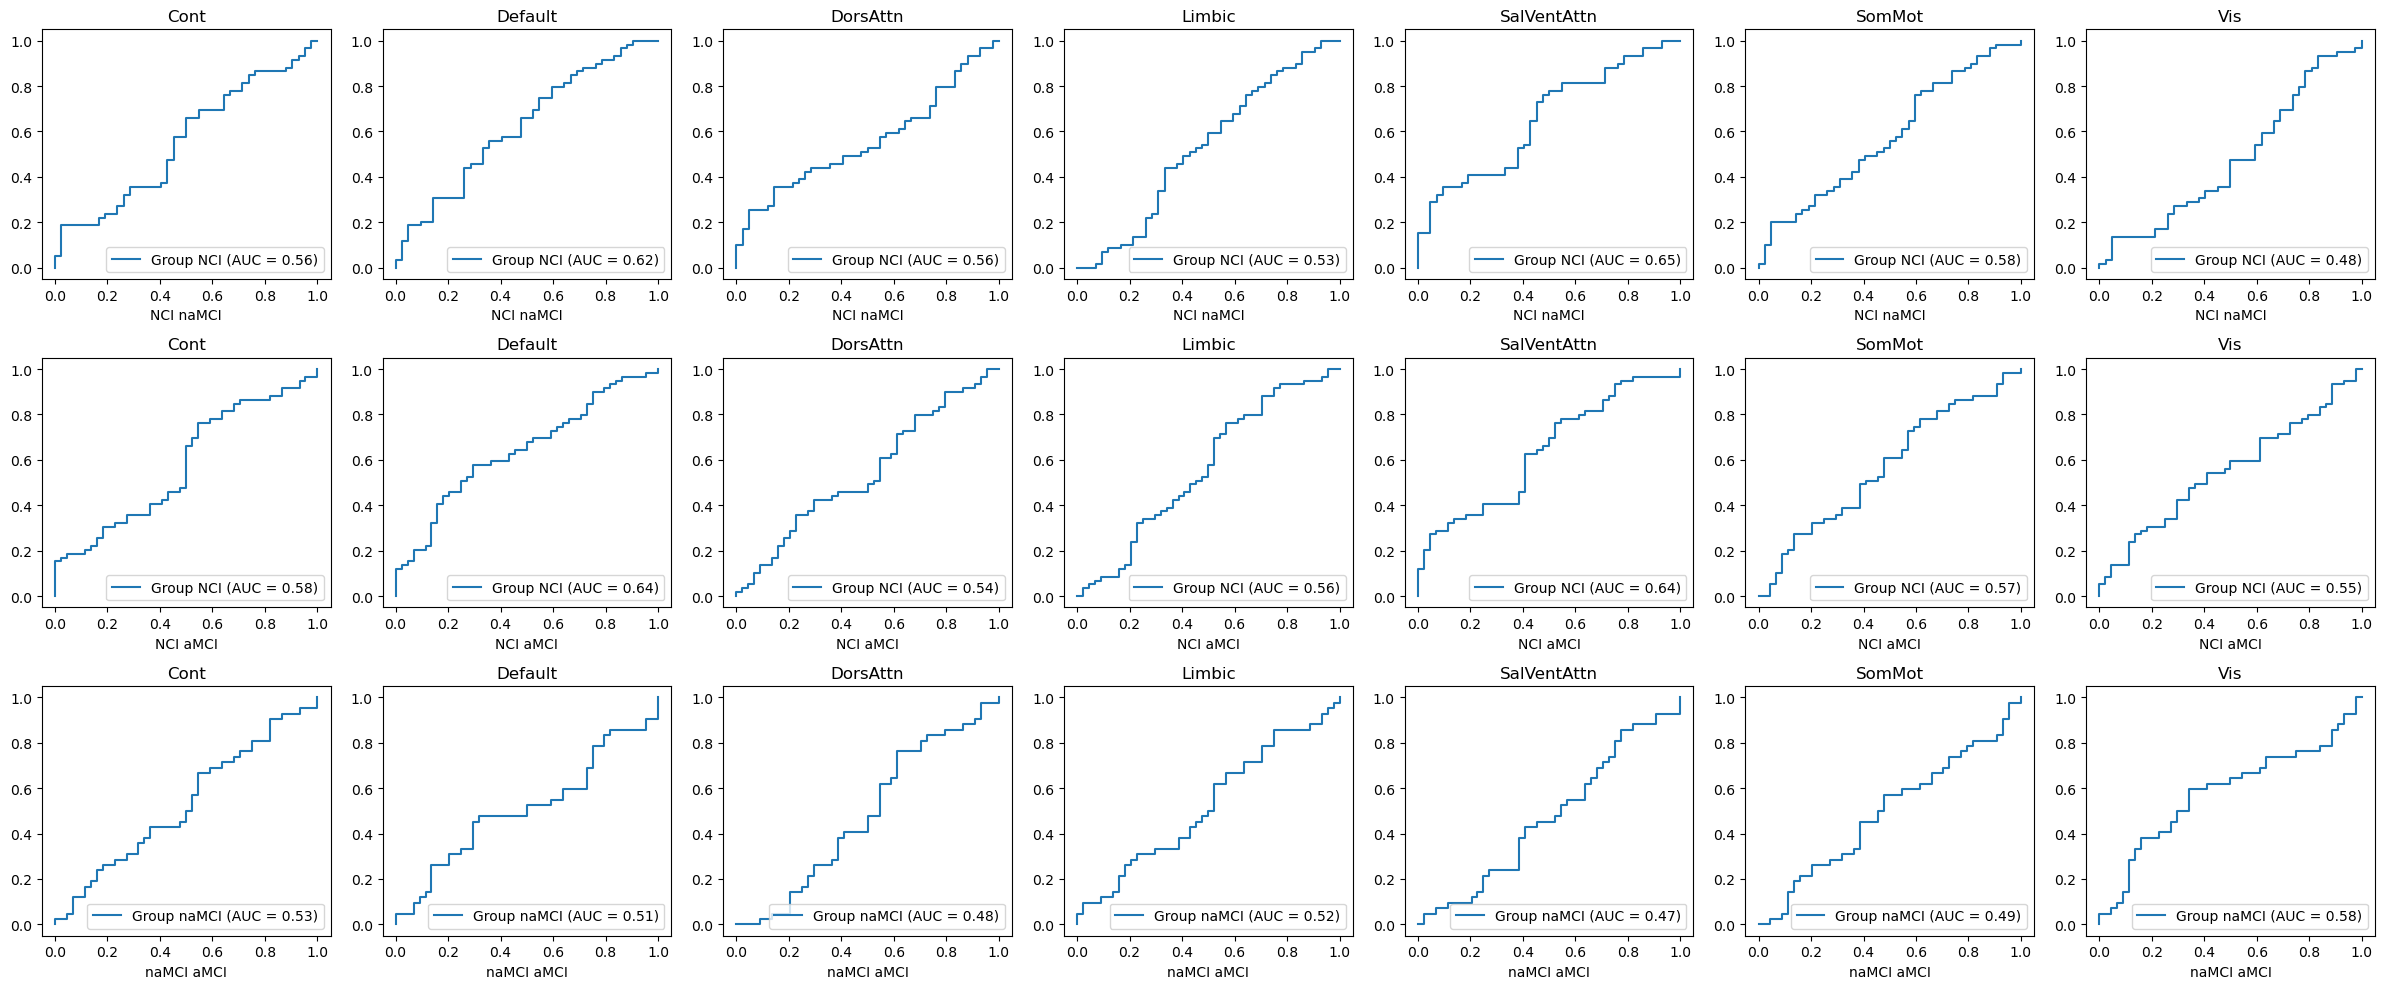

In [ ]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import combinations


# 创建子图
fig, axs = plt.subplots(3, 7, figsize=(24, 10))
cm_rsq_tbl = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/co-wei-cfc_int.csv")
groups = cm_rsq_tbl["Group"].unique()
for j, net_lab in enumerate(net_labs):
    net_cm_rsq_tbl = cm_rsq_tbl[cm_rsq_tbl.net == net_lab]
    # 遍历每对组合
    for i, (group1, group2) in enumerate(combinations(groups, 2)):
        print(group1, group2)
        # 根据组别选择数据
        sub_tbl = net_cm_rsq_tbl[net_cm_rsq_tbl.Group.isin([group1, group2])]
        sub_tbl["Group"] = sub_tbl["Group"].map({group1: 1, group2: 0})
        # print(sub_tbl)
        sub_tbl.dropna()
        # 计算 ROC 曲线
        fpr_group1, tpr_group1, _ = roc_curve(sub_tbl["Group"], sub_tbl["rsq"])
        auc_group1 = auc(fpr_group1, tpr_group1)

        # 绘制 ROC 曲线
        axs[i, j].plot(
            fpr_group1, tpr_group1, label=f"Group {group1} (AUC = {auc_group1:.2f})"
        )
        axs[i, j].set_xlabel(group1+" "+group2)
        # axs[i, j].set_ylabel("True PR")
        axs[i, j].set_title(net_lab)
        axs[i, j].legend(loc="lower right")

# 调整布局
plt.tight_layout()
plt.show()